# Building a Signal System

In [91]:
import pandas as pd

df = pd.read_parquet('spy.pq.gzip')
df.index = df.index.tz_convert('US/Eastern')
df.dtypes

Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
Dividends        float64
Stock Splits     float64
Capital Gains    float64
dtype: object

# Signal Systems 
| Signal | Threshold | What it measures |
|---|---|---|
| SPY drawdown from 52w high | > 10% | Correction is real and underway |
| VIX level | > 30 | Fear/panic exhaustion |
| % S&P stocks above 50-day MA | < 30% | Broad market selloff, everyone is capitulating |
| SPY 20-day return z-score | < -1.5 std | Fear extreme relative to trailing year |
| RSI on SPY (14-day, Wilder) | < 35 | SPY statistically oversold |

**Entry:** 5 of 5 signals trigger simultaneously (with 60-day cooldown)

In [ ]:
# SPY Drawdown signal
signal_df = df[['Close']].copy()
signal_df['high_52w'] = signal_df['Close'].rolling(252).max()
signal_df['drawdown'] = (signal_df['Close'] - signal_df['high_52w']) / signal_df['high_52w']
signal_df['drawdown_signal'] = signal_df['drawdown'] < -0.10
signal_df[signal_df['drawdown_signal']].head()

,Close,high_52w,drawdown,drawdown_signal
Date,,,,
1997-04-11 00:00:00-04:00,44.505741,49.471958,-0.100384,True
1997-10-27 00:00:00-05:00,53.284405,60.007046,-0.112031,True
1998-08-14 00:00:00-04:00,65.510994,73.188683,-0.104903,True
1998-08-27 00:00:00-04:00,64.044907,73.188683,-0.124934,True
1998-08-28 00:00:00-04:00,63.813461,73.188683,-0.128097,True


In [ ]:
# VIX signal
import yfinance as yf

vix_close       = yf.Ticker('^VIX').history(period='max')['Close']
vix_close.index = vix_close.index.tz_convert('US/Eastern')

vix_close.index = vix_close.index.normalize()
df.index        = df.index.normalize()

signal_df = signal_df.merge(vix_close.rename('Close_vix'), left_index=True, right_index=True, how='left')
signal_df['vix_signal'] = signal_df['Close_vix'] > 30
signal_df[signal_df['vix_signal']].head()

,Close,high_52w,drawdown,drawdown_signal,Close_vix,vix_signal
Date,,,,,,
1997-10-27 00:00:00-05:00,53.284405,60.007046,-0.112031,True,31.120001,True
1997-10-28 00:00:00-05:00,56.359276,60.007046,-0.060789,False,31.219999,True
1997-10-29 00:00:00-05:00,56.206486,60.007046,-0.063335,False,33.750000,True
1997-10-30 00:00:00-05:00,54.965073,60.007046,-0.084023,False,38.200001,True
1997-10-31 00:00:00-05:00,56.263763,60.007046,-0.062381,False,35.090000,True


In [ ]:
# Breadth Thrust (% Stocks Above 50-Day MA)
import os
from datetime import datetime, timedelta
from io import StringIO
import requests

CACHE = 'sp500_tickers_close.pq.gzip'
STALE_AFTER_DAYS = 1

cache_is_stale = (
    not os.path.exists(CACHE) or
    datetime.fromtimestamp(os.path.getmtime(CACHE)) < datetime.now() - timedelta(days=STALE_AFTER_DAYS)
)

if cache_is_stale:
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    html = StringIO(requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text)
    tickers = pd.read_html(html)[0]['Symbol'].tolist()
    ticker_data = yf.download(tickers=tickers, period='max')['Close']
    ticker_data.to_parquet(CACHE)
else:
    ticker_data = pd.read_parquet(CACHE)

ticker_data.index = ticker_data.index.tz_localize('US/Eastern')
ticker_data.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02 00:00:00-05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.088155,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-03 00:00:00-05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.089465,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-04 00:00:00-05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.089683,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-05 00:00:00-05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.087719,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-08 00:00:00-05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.087501,NaN,NaN,NaN,NaN,NaN,NaN


In [95]:
above_50d      = ticker_data > ticker_data.rolling(50).mean()
breadth_thrust = above_50d.mean(axis=1).rename('breadth_thrust').to_frame()

signal_df = signal_df.merge(breadth_thrust, how='left', on='Date')

signal_df['breadth_thrust_signal'] = signal_df['breadth_thrust'] > 0.30

signal_df[signal_df['breadth_thrust_signal']].head()

,Close,high_52w,drawdown,drawdown_signal,Close_vix,vix_signal,breadth_thrust,breadth_thrust_signal
Date,,,,,,,,
1993-01-29 00:00:00-05:00,24.175377,NaN,NaN,False,12.42,False,0.365805,True
1993-02-01 00:00:00-05:00,24.347322,NaN,NaN,False,12.33,False,0.383698,True
1993-02-02 00:00:00-05:00,24.398891,NaN,NaN,False,12.25,False,0.385686,True
1993-02-03 00:00:00-05:00,24.656841,NaN,NaN,False,12.12,False,0.407555,True
1993-02-04 00:00:00-05:00,24.759998,NaN,NaN,False,12.29,False,0.405567,True


In [96]:
# Fear proxy: SPY 20-day return z-score (negative = fear)
spy_ret = signal_df['Close'].pct_change(20)
signal_df['fear_zscore'] = (spy_ret - spy_ret.rolling(252).mean()) / spy_ret.rolling(252).std()
signal_df['fear_zscore_signal'] = signal_df['fear_zscore'] < -1.5  # 1.5 std below normal = fear extreme
signal_df[signal_df['fear_zscore_signal']].head()

,Close,high_52w,drawdown,drawdown_signal,Close_vix,vix_signal,breadth_thrust,breadth_thrust_signal,fear_zscore,fear_zscore_signal
Date,,,,,,,,,,
1994-02-24 00:00:00-05:00,26.280840,27.232677,-0.034952,False,15.96,False,0.270378,False,-1.501561,True
1994-02-25 00:00:00-05:00,26.404230,27.232677,-0.030421,False,14.80,False,0.266402,False,-1.776233,True
1994-02-28 00:00:00-05:00,26.404230,27.232677,-0.030421,False,14.87,False,0.282306,False,-1.920983,True
1994-03-01 00:00:00-05:00,26.298464,27.232677,-0.034305,False,15.83,False,0.270378,False,-2.582301,True
1994-03-02 00:00:00-05:00,26.333736,27.232677,-0.033010,False,16.08,False,0.246521,False,-2.147738,True


In [ ]:
# RSI Signal
delta = signal_df['Close'].diff()

# Separate gains and losses
gain = delta.where(delta > 0, 0)
loss = delta.where(delta < 0, 0).abs()

# Calculate average gain and loss (Wilder smoothing)
avg_gain = gain.ewm(com=13, min_periods=14).mean()
avg_loss = loss.ewm(com=13, min_periods=14).mean()

# Calculate RSI
rs = avg_gain / avg_loss
signal_df['RSI'] = 100 - (100 / (1 + rs))

signal_df['RSI_signal'] = signal_df['RSI'] < 35
signal_df[signal_df['RSI_signal']].head()

,Close,high_52w,drawdown,drawdown_signal,Close_vix,vix_signal,breadth_thrust,breadth_thrust_signal,fear_zscore,fear_zscore_signal,RSI,RSI_signal
Date,,,,,,,,,,,,
1993-02-18 00:00:00-05:00,23.883072,NaN,NaN,False,15.56,False,0.294235,False,NaN,False,31.343329,True
1993-04-23 00:00:00-04:00,24.185915,NaN,NaN,False,13.36,False,0.242545,False,NaN,False,34.227136,True
1993-04-26 00:00:00-04:00,23.995878,NaN,NaN,False,15.25,False,0.198807,False,NaN,False,30.330957,True
1994-03-29 00:00:00-05:00,25.581511,27.232677,-0.060632,False,16.49,False,0.145129,False,-2.062906,True,27.877753,True
1994-03-30 00:00:00-05:00,25.226946,27.232677,-0.073652,False,18.59,False,0.107356,False,-2.950538,True,23.387112,True


In [ ]:
signal_df['composite_score'] = signal_df[[c for c in signal_df.columns if 'signal' in c]].sum(axis=1)

sample_df = signal_df[
      (signal_df.index >= '2012-01-01')
    & (signal_df.index <= '2026-01-01')
]
dips = sample_df[sample_df['composite_score'] >= 5 ].index
dips

DatetimeIndex(['2022-04-26 00:00:00-04:00', '2022-04-27 00:00:00-04:00',
               '2025-04-03 00:00:00-04:00'],
              dtype='datetime64[ns, US/Eastern]', name='Date', freq=None)

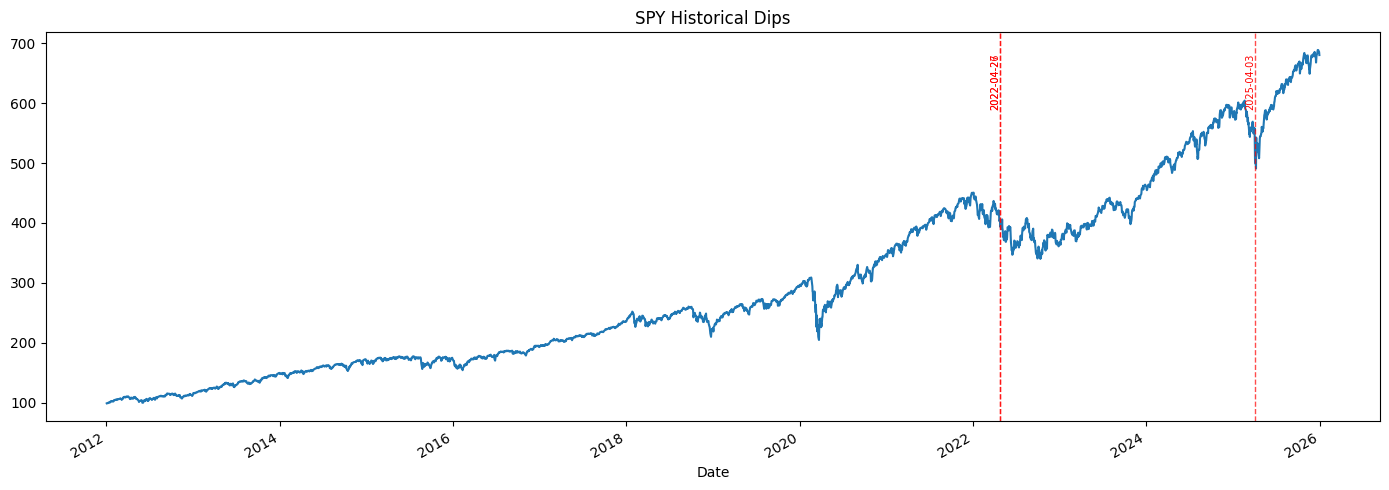

In [107]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
sample_df['Close'].plot(ax=ax, title='SPY Historical Dips')

for date in dips:
    ax.axvline(x=date, color='red', linestyle='--', alpha=0.7, linewidth=1)
    ax.text(date, ax.get_ylim()[1] * 0.95, date.strftime('%Y-%m-%d'),
            rotation=90, fontsize=7, color='red', ha='right', va='top')

plt.tight_layout()
plt.show()
